# 03 – Autoencoder + XGBoost (ideia do professor)

Pipeline sugerido pelo professor:
```
Imagens → CNN Encoder (treino não-supervisionado em TODO o dataset)
        → Latent Space (~2048 dim, reduzido para ~512 com PCA)
        → XGBoost / SVM (treino supervisionado só nas 5519 imagens labeled)
```

**Vantagens:**
- Aproveita as ~19k imagens não-labeladas para aprender representações
- XGBoost lida melhor com classes desequilibradas via `scale_pos_weight`
- Muito mais rápido de treinar que uma CNN completa

In [ ]:
#!pip install xgboost

In [1]:
import os, json, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b7
from torchvision import transforms
import cv2
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb
import joblib

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED       = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATASET_DIR  = os.environ.get('OUT_DIR', './dataset_processed')
MODEL_PATH   = '../../MIQR-CC-Dataset/training/models/efficientnet_b7.pth'
TARGET_SIZE  = (512, 512)
BATCH_SIZE   = 4
PCA_COMPONENTS = 256
NUM_CLASSES  = 4
os.makedirs('./models', exist_ok=True)
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────
DATASET_PROCESSED = os.environ.get('OUT_DIR',        './dataset_processed')  # labeled
DATASET_RAW       = os.environ.get('RAW_BASE_DIR',   '../../dataset')
TARGET_SIZE       = (128, 128)  # mais pequeno para o autoencoder — suficiente
BATCH_SIZE_AE     = 64
EPOCHS_AE         = 30
LR_AE             = 1e-3
LATENT_DIM        = 512
PCA_COMPONENTS    = 256    # reduzir antes do XGBoost
AE_PATH           = './models/autoencoder.pth'
os.makedirs('./models', exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────

## 1. Carregar Dados

In [3]:
PHASES = ['train', 'val', 'test']
class_names = sorted([d for d in os.listdir(os.path.join(DATASET_DIR, 'train'))
                       if os.path.isdir(os.path.join(DATASET_DIR, 'train', d))])
NUM_CLASSES = len(class_names)
print('Classes:', class_names)

data = {phase: {'images': [], 'labels': []} for phase in PHASES}
for phase in PHASES:
    for i, cls in enumerate(class_names):
        cls_dir = os.path.join(DATASET_DIR, phase, cls)
        if not os.path.isdir(cls_dir): continue
        files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                 if f.lower().endswith('.png')]
        data[phase]['images'].extend(files)
        data[phase]['labels'].extend([i] * len(files))

for phase in PHASES:
    print(f'{phase}: {len(data[phase]["images"])} imagens')

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
train: 1067 imagens
val: 234 imagens
test: 267 imagens


## 2. Dataset e Transforms

In [4]:
def repeat_channels(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

from monai.transforms import (LoadImage, EnsureChannelFirst, Resize,
                               NormalizeIntensity, Lambda, ToTensor, Compose)

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize(TARGET_SIZE),
    NormalizeIntensity(),
    Lambda(repeat_channels),
    ToTensor()
])

class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        return self.transforms(self.image_files[idx]), self.labels[idx]

## 3. Carregar EfficientNet-B7 treinado no notebook 02

In [5]:
# Carregar EfficientNet-B7 treinado no notebook 02
#effnet = efficientnet_b7(weights=None)
#effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
#effnet.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

# Remover o classificador final — ficar só com o extractor de features
#effnet.classifier = nn.Identity()
#effnet.eval().to(DEVICE)
#print('✅ EfficientNet-B7 carregado (sem head)')

# Verificar dimensão das features
#with torch.no_grad():
#    dummy = torch.zeros(1, 3, 512, 512).to(DEVICE)
#    out = effnet(dummy)
#    print(f'Dimensão das features: {out.shape}')  # deve ser (1, 2560)

AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [6]:
# Carregar para CPU primeiro — evita OOM
effnet = efficientnet_b7(weights=None)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
effnet.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))

# Remover o classificador
effnet.classifier = nn.Identity()
effnet.eval()
print('✅ EfficientNet-B7 carregado em CPU')

✅ EfficientNet-B7 carregado em CPU


## 4. Extrair Features

In [ ]:
#@torch.no_grad()
#def extract_features(image_files, labels):
#    ds = ERCPDataset(image_files, labels, val_transforms)
#    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
#    features, all_labels = [], []
#    for imgs, lbls in tqdm(dl, desc='Extraindo features'):
#        feats = effnet(imgs.to(DEVICE))
#        features.append(feats.cpu().numpy())
#        all_labels.extend(lbls.numpy())
#    return np.vstack(features), np.array(all_labels)

#X_train, y_train = extract_features(data['train']['images'], data['train']['labels'])
#X_val,   y_val   = extract_features(data['val']['images'],   data['val']['labels'])
#X_test,  y_test  = extract_features(data['test']['images'],  data['test']['labels'])
#print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

In [9]:
#@torch.no_grad()
#def extract_features(image_files, labels):
#    ds = ERCPDataset(image_files, labels, val_transforms)
#    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
#    features, all_labels = [], []
    
#    effnet.to(DEVICE)  # mover para GPU só aqui
#    for imgs, lbls in tqdm(dl, desc='Extraindo features'):
#        feats = effnet(imgs.to(DEVICE))
#        features.append(feats.cpu().numpy())  # guardar em CPU imediatamente
#        all_labels.extend(lbls.numpy())
#    effnet.to('cpu')   # libertar GPU logo depois
#    torch.cuda.empty_cache()
    
#    return np.vstack(features), np.array(all_labels)

#X_train, y_train = extract_features(data['train']['images'], data['train']['labels'])
#X_val,   y_val   = extract_features(data['val']['images'],   data['val']['labels'])
#X_test,  y_test  = extract_features(data['test']['images'],  data['test']['labels'])
#print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [10]:
# 1. Forçar o modelo a ficar na CPU
effnet = effnet.to('cpu')

# 2. Criar uma versão da função adaptada para CPU
@torch.no_grad()
def extract_features_cpu(image_files, labels):
    ds = ERCPDataset(image_files, labels, val_transforms)
    # Aumentar num_workers ajuda a carregar imagens mais rápido em paralelo na CPU
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    features, all_labels = [], []
    
    for imgs, lbls in tqdm(dl, desc='Extraindo features na CPU'):
        # Passa as imagens e o modelo na CPU diretamente
        feats = effnet(imgs.to('cpu'))
        features.append(feats.numpy())
        all_labels.extend(lbls.numpy())
        
    return np.vstack(features), np.array(all_labels)

# 3. Correr a extração
X_train, y_train = extract_features_cpu(data['train']['images'], data['train']['labels'])
X_val,   y_val   = extract_features_cpu(data['val']['images'],   data['val']['labels'])
X_test,  y_test  = extract_features_cpu(data['test']['images'],  data['test']['labels'])

print(f'✅ Concluído! Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Extraindo features na CPU: 100%|██████████| 67/67 [00:40<00:00,  1.65it/s]

✅ Concluído! Train: (1067, 2560) | Val: (234, 2560) | Test: (267, 2560)


## 6. Redução Dimensional com PCA

PCA 256 componentes explicam 93.1% da variância


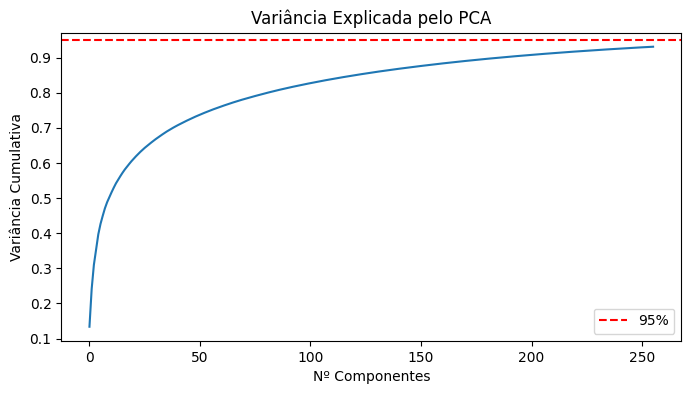

['models/pca.pkl']

In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_s)
X_val_pca   = pca.transform(X_val_s)
X_test_pca  = pca.transform(X_test_s)

explained = np.cumsum(pca.explained_variance_ratio_)
print(f'PCA {PCA_COMPONENTS} componentes explicam {explained[-1]*100:.1f}% da variância')

plt.figure(figsize=(8, 4))
plt.plot(explained)
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.title('Variância Explicada pelo PCA')
plt.xlabel('Nº Componentes'); plt.ylabel('Variância Cumulativa')
plt.legend(); plt.savefig('pca_variance.png', dpi=150); plt.show()

# Guardar para ensemble
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(pca,    'models/pca.pkl')

## 7. Treino XGBoost

In [12]:
from collections import Counter

# Calcular scale_pos_weight por classe (para desbalanceamento)
class_counts = Counter(y_train)
max_count = max(class_counts.values())
sample_weight = np.array([max_count / class_counts[y] for y in y_train])

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',   # GPU: mudar para 'gpu_hist'
    early_stopping_rounds=30
)

print('A treinar XGBoost...')
xgb_model.fit(
    X_train_pca, y_train,
    sample_weight=sample_weight,
    eval_set=[(X_val_pca, y_val)],
    verbose=50
)

joblib.dump(xgb_model, 'models/xgboost_model.pkl')
print('✅ XGBoost guardado')

A treinar XGBoost...
[0]	validation_0-mlogloss:1.37851


/mounts/mecd-ap-g4/.local/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [13:57:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-mlogloss:1.33358
[66]	validation_0-mlogloss:1.35008
✅ XGBoost guardado


## 8. Avaliação XGBoost no Teste


🎯 XGBoost Test F1-Score (macro): 0.3165  (baseline: 0.738)
   Delta vs baseline: -0.4215

               precision    recall  f1-score   support

Biliary_Leaks     1.0000    0.0588    0.1111        17
    Lithiasis     0.4808    0.8130    0.6042       123
       Normal     0.4737    0.2093    0.2903        43
    Stricture     0.4103    0.1905    0.2602        84

     accuracy                         0.4719       267
    macro avg     0.5912    0.3179    0.3165       267
 weighted avg     0.4905    0.4719    0.4140       267

✅ Probabilidades XGBoost guardadas para ensemble


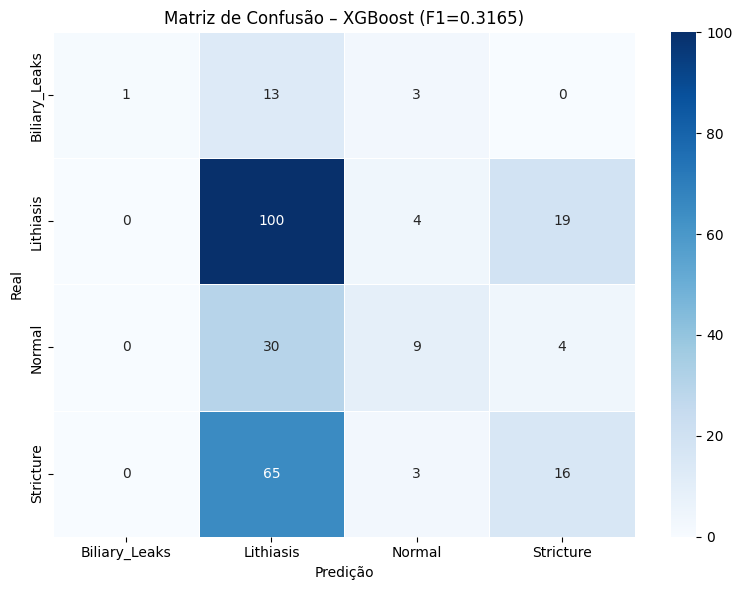

In [13]:
xgb_preds = xgb_model.predict(X_test_pca)
xgb_probs = xgb_model.predict_proba(X_test_pca)

xgb_f1 = f1_score(y_test, xgb_preds, average='macro')
print(f'\n🎯 XGBoost Test F1-Score (macro): {xgb_f1:.4f}  (baseline: 0.738)')
print(f'   Delta vs baseline: {xgb_f1 - 0.738:+.4f}\n')
print(classification_report(y_test, xgb_preds, target_names=class_names, digits=4))

# Guardar probabilidades para ensemble
np.save('test_probs_xgboost.npy', xgb_probs)
print('✅ Probabilidades XGBoost guardadas para ensemble')

# Matriz de confusão
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', linewidths=0.5)
plt.title(f'Matriz de Confusão – XGBoost (F1={xgb_f1:.4f})')
plt.xlabel('Predição'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_xgboost.png', dpi=150)
plt.show()

## 9. (Opcional) SVM como Alternativa

In [14]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale',
                class_weight='balanced',
                probability=True, random_state=SEED)

# Treinar em train+val para maximizar dados
X_trainval = np.vstack([X_train_pca, X_val_pca])
y_trainval = np.concatenate([y_train, y_val])

print('A treinar SVM (pode demorar alguns minutos)...')
svm_model.fit(X_trainval, y_trainval)

svm_preds = svm_model.predict(X_test_pca)
svm_probs = svm_model.predict_proba(X_test_pca)
svm_f1    = f1_score(y_test, svm_preds, average='macro')

print(f'\n🎯 SVM Test F1-Score (macro): {svm_f1:.4f}')
print(classification_report(y_test, svm_preds, target_names=class_names, digits=4))

joblib.dump(svm_model, 'models/svm_model.pkl')
np.save('test_probs_svm.npy', svm_probs)

A treinar SVM (pode demorar alguns minutos)...

🎯 SVM Test F1-Score (macro): 0.3451
               precision    recall  f1-score   support

Biliary_Leaks     0.0000    0.0000    0.0000        17
    Lithiasis     0.4922    0.7724    0.6013       123
       Normal     0.5000    0.3488    0.4110        43
    Stricture     0.5610    0.2738    0.3680        84

     accuracy                         0.4981       267
    macro avg     0.3883    0.3488    0.3451       267
 weighted avg     0.4838    0.4981    0.4589       267

